In [ ]:
# GWAS pipeline run on the KCL CREATE cluster (SLURM)

## Imports

In [1]:
# all imports required for notebook to run + making sure i'm in the correct directory

import os as os
os.chdir("/scratch/users/k21049150/HNF1A")
print(os.getcwd())

import pandas as pd

import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc

import glob

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

import requests

import time

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/users/k21049150/HNF1A'

## Data Exploration

In [3]:
df = pd.read_parquet("credible_set/part-00000-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet")

# what are the different columns in each .parquet file?
print(df.columns)

Index(['studyLocusId', 'studyId', 'variantId', 'chromosome', 'position',
       'region', 'beta', 'zScore', 'pValueMantissa', 'pValueExponent',
       'effectAlleleFrequencyFromSource', 'standardError',
       'subStudyDescription', 'qualityControls', 'finemappingMethod',
       'credibleSetIndex', 'credibleSetlog10BF', 'purityMeanR2', 'purityMinR2',
       'locusStart', 'locusEnd', 'sampleSize', 'ldSet', 'locus', 'confidence',
       'studyType', 'isTransQtl'],
      dtype='object')


In [4]:
# visulaising what a typical row could look like in the .parquet file
df.head()

,studyLocusId,studyId,variantId,chromosome,position,region,beta,zScore,pValueMantissa,pValueExponent,...,purityMeanR2,purityMinR2,locusStart,locusEnd,sampleSize,ldSet,locus,confidence,studyType,isTransQtl
0,5623dafc4eb4d24314b35f9e9120805a,gtex_ge_brain_cerebellum_ensg00000241860,1_14677_G_A,1,14677,chr1:-826138-1173862,1.052620,NaN,6.103,-7,...,NaN,NaN,NaN,NaN,NaN,None,"[{'is95CredibleSet': True, 'is99CredibleSet': ...",SuSiE fine-mapped credible set with in-sample LD,eqtl,False
1,e62f70cd4aa982aad471ba67e3915ec3,gtex_tx_brain_cerebellum_enst00000491962,1_14677_G_A,1,14677,chr1:-826138-1173862,1.177820,NaN,9.527,-8,...,NaN,NaN,NaN,NaN,NaN,None,"[{'is95CredibleSet': True, 'is99CredibleSet': ...",SuSiE fine-mapped credible set with in-sample LD,eqtl,False
2,746fe96203ae5ad1508209560aa398f8,gtex_exon_brain_frontal_cortex_ensg00000228794...,1_17730_C_A,1,17730,chr1:-157989-1842011,0.980972,NaN,1.786,-6,...,NaN,NaN,NaN,NaN,NaN,None,"[{'is95CredibleSet': True, 'is99CredibleSet': ...",SuSiE fine-mapped credible set with in-sample LD,eqtl,False
3,b2a84663f3598e8df1649a802aa8c34f,GCST90474478,1_51427_T_G,1,51427,None,-0.448027,NaN,6.331,-11,...,NaN,NaN,NaN,NaN,8282.0,"[{'tagVariantId': '1_51427_T_G', 'r2Overall': ...","[{'is95CredibleSet': True, 'is99CredibleSet': ...",PICS fine-mapped credible set extracted from s...,gwas,None
4,b601b39829682421fb99cfb78485ffb4,GCST90474483,1_51427_T_G,1,51427,None,-0.437719,NaN,1.275,-10,...,NaN,NaN,NaN,NaN,8282.0,"[{'tagVariantId': '1_51427_T_G', 'r2Overall': ...","[{'is95CredibleSet': True, 'is99CredibleSet': ...",PICS fine-mapped credible set extracted from s...,gwas,None


In [4]:
# how many rows are we working with?
df.shape

(17461, 27)

In [5]:
# learning more about the credible sites dataset

# how many different study types there are
print(df['studyType'].value_counts())

print(df['finemappingMethod'].value_counts())

print(df['confidence'].value_counts())

studyType
eqtl      9524
tuqtl     3135
gwas      3111
sqtl      1497
sceqtl     157
pqtl        37
Name: count, dtype: int64
finemappingMethod
SuSie        14379
PICS          1567
SuSiE-inf     1515
Name: count, dtype: int64
confidence
SuSiE fine-mapped credible set with in-sample LD                   14379
SuSiE fine-mapped credible set with out-of-sample LD                1515
PICS fine-mapped credible set extracted from summary statistics     1148
PICS fine-mapped credible set based on reported top hit              419
Name: count, dtype: int64


In [6]:
# explode the locus column so each variant gets its own row
locus_df = df.explode('locus').reset_index(drop=True)

# the locus column is now dicts — expand into columns
locus_expanded = pd.json_normalize(locus_df['locus'])

# view these columns
locus_expanded.head()

,is95CredibleSet,is99CredibleSet,logBF,posteriorProbability,variantId,pValueMantissa,pValueExponent,beta,standardError,r2Overall
0,True,True,11.902182,0.95,1_14677_G_A,6.103,-7.0,1.052620,0.204029,NaN
1,True,True,14.308355,0.95,1_14677_G_A,9.527,-8.0,1.177820,0.212414,NaN
2,True,True,11.560530,0.95,1_17730_C_A,1.786,-6.0,0.980972,0.197784,NaN
3,True,True,NaN,1.00,1_51427_T_G,6.331,-11.0,-0.448027,0.997700,1.0
4,True,True,NaN,1.00,1_51427_T_G,1.275,-10.0,-0.437719,0.997700,1.0


In [7]:
locus_expanded.shape

(231411, 10)

In [8]:
# bring back the parent-level metadata we care about for each variant
meta_cols = ['studyLocusId', 'studyId', 'chromosome', 'position', 
             'finemappingMethod', 'confidence', 'studyType', 
             'locusStart', 'locusEnd', 'credibleSetIndex']

final_df = pd.concat([locus_df[meta_cols].reset_index(drop=True), locus_expanded], axis=1)

# view the final dataframe for that single .parquet file we were exploring, with variants for each region expanded
final_df.head()

,studyLocusId,studyId,chromosome,position,finemappingMethod,confidence,studyType,locusStart,locusEnd,credibleSetIndex,is95CredibleSet,is99CredibleSet,logBF,posteriorProbability,variantId,pValueMantissa,pValueExponent,beta,standardError,r2Overall
0,5623dafc4eb4d24314b35f9e9120805a,gtex_ge_brain_cerebellum_ensg00000241860,1,14677,SuSie,SuSiE fine-mapped credible set with in-sample LD,eqtl,NaN,NaN,1.0,True,True,11.902182,0.95,1_14677_G_A,6.103,-7.0,1.052620,0.204029,NaN
1,e62f70cd4aa982aad471ba67e3915ec3,gtex_tx_brain_cerebellum_enst00000491962,1,14677,SuSie,SuSiE fine-mapped credible set with in-sample LD,eqtl,NaN,NaN,1.0,True,True,14.308355,0.95,1_14677_G_A,9.527,-8.0,1.177820,0.212414,NaN
2,746fe96203ae5ad1508209560aa398f8,gtex_exon_brain_frontal_cortex_ensg00000228794...,1,17730,SuSie,SuSiE fine-mapped credible set with in-sample LD,eqtl,NaN,NaN,1.0,True,True,11.560530,0.95,1_17730_C_A,1.786,-6.0,0.980972,0.197784,NaN
3,b2a84663f3598e8df1649a802aa8c34f,GCST90474478,1,51427,PICS,PICS fine-mapped credible set extracted from s...,gwas,NaN,NaN,NaN,True,True,NaN,1.00,1_51427_T_G,6.331,-11.0,-0.448027,0.997700,1.0
4,b601b39829682421fb99cfb78485ffb4,GCST90474483,1,51427,PICS,PICS fine-mapped credible set extracted from s...,gwas,NaN,NaN,NaN,True,True,NaN,1.00,1_51427_T_G,1.275,-10.0,-0.437719,0.997700,1.0


In [9]:
final_df.shape

(231411, 20)

In [ ]:
# step 1: find all the parquet files in your folder
# glob.glob finds every file matching that pattern
files = glob.glob("credible_set/*.parquet")
print(f"Found {len(files)} parquet files to process")


# step 2: loop through each file, filter and collect
all_dfs = []  # empty list to collect results from each file

for i, f in enumerate(files):
    
    # read the file
    tmp = pd.read_parquet(f)
    
    # keep GWAS studies only — drop eQTL, sQTL etc.
    tmp = tmp[tmp['studyType'] == 'gwas']
    
    # if no GWAS rows in this file, skip it entirely
    if tmp.empty:
        continue
    
    # explode the locus column, this turns 1 row per locus
    # into 1 row per variant within that locus
    tmp = tmp.explode('locus').reset_index(drop=True)
    
    # expand the locus column (which contains dicts) into proper separate columns
    locus_exp = pd.json_normalize(tmp['locus'])
    
    # choose which metadata columns to keep from the parent locus
    meta_cols = ['studyLocusId', 'studyId', 'chromosome', 'position',
                 'finemappingMethod', 'confidence', 'studyType',
                 'locusStart', 'locusEnd', 'credibleSetIndex']
    
    # stick the metadata and expanded locus columns together
    tmp = pd.concat([tmp[meta_cols].reset_index(drop=True), locus_exp], axis=1)
    
    # keep only variants in the 95% credible set
    tmp = tmp[tmp['is95CredibleSet'] == True]
    
    # add this file's results to collection
    all_dfs.append(tmp)
    
    # progress update
    print(f"[{i+1}/{len(files)}] Done: {f.split('/')[-1]} — {len(tmp)} variants kept")

# step 3: combine everything into one single dataframe
gwas_df = pd.concat(all_dfs, ignore_index=True)


# step 4: print a summary of what we have
print(f"Done!")
print(f"Total Variants In GWAS Studies: {gwas_df.shape[0]:,}")
print(f"Unique Studies: {gwas_df['studyId'].nunique():,}")
print(f"Columns: {gwas_df.shape[1]}")
print(f"\nPreview:")

Found 200 parquet files to process
[1/200] Done: part-00144-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 68431 variants kept
[2/200] Done: part-00137-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 190787 variants kept
[3/200] Done: part-00146-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 192240 variants kept
[4/200] Done: part-00038-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 123353 variants kept
[5/200] Done: part-00077-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 91668 variants kept
[6/200] Done: part-00027-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 20223 variants kept
[7/200] Done: part-00076-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 86471 variants kept
[8/200] Done: part-00084-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 157165 variants kept
[9/200] Done: part-00048-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet — 159344 variants kept
[10/200] Done: part-0014

## Filtering GWAS Studies From Credible Set Data

In [ ]:
# looped over all parquet files
# kept only GWAS studies
# kept only is95CredibleSet == True
# saved chunks to disk

files = glob.glob("credible_set/*.parquet")
print(f"Found {len(files)} parquet files to process")

# create an output folder to save intermediate results
os.makedirs("gwas_filtered", exist_ok=True)

for i, f in enumerate(files):
    
    tmp = pd.read_parquet(f)
    tmp = tmp[tmp['studyType'] == 'gwas']
    
    if tmp.empty:
        print(f"[{i+1}/{len(files)}] Skipped (no GWAS): {f.split('/')[-1]}")
        continue
    
    tmp = tmp.explode('locus').reset_index(drop=True)
    locus_exp = pd.json_normalize(tmp['locus'])
    
    meta_cols = ['studyLocusId', 'studyId', 'chromosome', 'position',
                 'finemappingMethod', 'confidence', 'studyType',
                 'locusStart', 'locusEnd', 'credibleSetIndex']
    
    tmp = pd.concat([tmp[meta_cols].reset_index(drop=True), locus_exp], axis=1)
    tmp = tmp[tmp['is95CredibleSet'] == True]
    
    # save this file's results to disk immediately
    # then clear it from memory
    out_path = f"gwas_filtered/chunk_{i:03d}.parquet"
    tmp.to_parquet(out_path, index=False)
    
    # explicitly delete and free memory
    del tmp, locus_exp
    
    print(f"[{i+1}/{len(files)}] Done: {f.split('/')[-1]}")

print("All Files Processed")

# now load all the small filtered chunks together
# these are much smaller so this is safe
chunks = glob.glob("gwas_filtered/chunk_*.parquet")
gwas_df = pd.read_parquet(chunks)

print(f"Total variants: {gwas_df.shape[0]:,}")
print(f"Unique studies: {gwas_df['studyId'].nunique():,}")
gwas_df.head()

Found 200 parquet files to process
[1/200] Done: part-00144-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[2/200] Done: part-00137-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[3/200] Done: part-00146-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[4/200] Done: part-00038-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[5/200] Done: part-00077-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[6/200] Done: part-00027-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[7/200] Done: part-00076-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[8/200] Done: part-00084-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[9/200] Done: part-00048-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[10/200] Done: part-00145-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[11/200] Done: part-00160-4cc70612-e114-4f99-812f-a49695775600-c000.snappy.parquet
[12/200] Done: part-00136-4cc70612-e114-4f99-812f-a4969577560

In [6]:
# built a BED file of all credible-set variants with chromosome, position, variant ID, PP, study ID
# this is the master variant file

import pandas as pd
import glob
import os

os.chdir('/scratch/users/k21049150/HNF1A')

chunks = glob.glob("gwas_filtered/chunk_*.parquet")
print(f"Found {len(chunks)} chunk files")

# keep standard chromosomes only
valid_chroms = [str(i) for i in range(1, 23)] + ['X', 'Y']

# open a BED file to write to
with open("gwas_credible_set.bed", "w") as bed_out:
    
    for i, c in enumerate(chunks):
        
        # load ONLY the columns we actually need — much lighter
        tmp = pd.read_parquet(c, columns=[
            'chromosome', 'variantId', 
            'posteriorProbability', 'studyId', 'is95CredibleSet'
        ])
        
        # keep 95% credible set only
        tmp = tmp[tmp['is95CredibleSet'] == True]
        
        # drop non-standard chromosomes
        tmp = tmp[tmp['chromosome'].isin(valid_chroms)]
        
        if tmp.empty:
            print(f"[{i+1}/{len(chunks)}] Skipped (no standard chroms)")
            continue
            
        # errors='coerce' turns bad values into NaN instead of crashing
        tmp['pos'] = tmp['variantId'].str.split('_').str[1]
        tmp['pos'] = pd.to_numeric(tmp['pos'], errors='coerce')
        
        # drop any rows where position couldn't be parsed
        tmp = tmp.dropna(subset=['pos'])
        tmp['pos'] = tmp['pos'].astype(int)
        
        # BED format needs start (0-based) and end
        tmp['start'] = tmp['pos'] - 1
        tmp['end'] = tmp['pos']
        
        # add chr prefix to match your BED file format
        tmp['chromosome'] = 'chr' + tmp['chromosome'].astype(str)
        
        # write to BED: chr, start, end, variantId, posteriorProbability, studyId
        tmp[['chromosome', 'start', 'end', 
             'variantId', 'posteriorProbability', 'studyId']].to_csv(
            bed_out, sep='\t', header=False, index=False
        )
        
        del tmp
        print(f"[{i+1}/{len(chunks)}] Done")

print("BED file written: gwas_credible_set.bed")

# quick check
os.system("wc -l gwas_credible_set.bed")
os.system("head -5 gwas_credible_set.bed")

Found 200 chunk files
[1/200] Done
[2/200] Done
[3/200] Done
[4/200] Done
[5/200] Done
[6/200] Done
[7/200] Done
[8/200] Done
[9/200] Done
[10/200] Done
[11/200] Done
[12/200] Done
[13/200] Done
[14/200] Done
[15/200] Done
[16/200] Done
[17/200] Done
[18/200] Done
[19/200] Done
[20/200] Done
[21/200] Done
[22/200] Done
[23/200] Done
[24/200] Done
[25/200] Done
[26/200] Done
[27/200] Done
[28/200] Done
[29/200] Done
[30/200] Done
[31/200] Done
[32/200] Done
[33/200] Done
[34/200] Done
[35/200] Done
[36/200] Done
[37/200] Done
[38/200] Done
[39/200] Done
[40/200] Done
[41/200] Done
[42/200] Done
[43/200] Done
[44/200] Done
[45/200] Done
[46/200] Done
[47/200] Done
[48/200] Done
[49/200] Done
[50/200] Done
[51/200] Done
[52/200] Done
[53/200] Done
[54/200] Done
[55/200] Done
[56/200] Done
[57/200] Done
[58/200] Done
[59/200] Done
[60/200] Done
[61/200] Done
[62/200] Done
[63/200] Done
[64/200] Done
[65/200] Done
[66/200] Done
[67/200] Done
[68/200] Done
[69/200] Done
[70/200] Done
[71/200

0

In [2]:
# intersected with HNF1A peaks for four tissues (islets, HepG2, D20_EP, EndoC) and loaded the hits_*.bed results
# this is the "variants in HNF1A peaks" filter

import pandas as pd
import os as os

os.chdir('/scratch/users/k21049150/HNF1A')

# define column names for the output
cols = ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId', 
        'posteriorProbability', 'studyId',
        'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']

# load each tissue
islets = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_Islets.bed', 
                     sep='\t', header=None, names=cols)
hepg2  = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_HepG2.bed',  
                     sep='\t', header=None, names=cols)
d20    = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_D20_EP.bed', 
                     sep='\t', header=None, names=cols)
endoc  = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_EndoC.bed',  
                     sep='\t', header=None, names=cols)

In [3]:
# how many credible sets and variants are there?

total_cs = 0
total_variants = 0
for f in glob.glob("/scratch/users/k21049150/HNF1A/credible_set/*.parquet"):
    t = pq.read_table(f, columns=["studyType", "locus"])
    t = t.filter(pc.equal(t["studyType"], "gwas"))      # GWAS only, not eQTL
    total_cs += t.num_rows
    total_variants += pc.sum(pc.list_value_length(t["locus"])).as_py() or 0

print("credible sets:", total_cs)
print("variant records:", total_variants)

credible sets: 1446959
variant records: 38919095


## Islet Analysis

In [4]:
# preview the most interesting one
# so in islets, there's close to ~5000 variants 

print(islets.shape)
islets.sort_values('posteriorProbability', ascending=False).head(10)

(4585, 12)


,gwas_chr,gwas_start,gwas_end,variantId,posteriorProbability,studyId,peak_chr,peak_start,peak_end,peak_name,peak_score,peak_strand
325,chr1,234960803,234960804,1_234960804_A_T,1.000000,GCST90662899,chr1,234960679,234960986,Islets_HNF1A_ab96777_peak_41,66,.
2925,chr19,58150867,58150868,19_58150868_C_T,1.000000,GCST90662895,chr19,58150696,58151070,Islets_HNF1A_ab96777_peak_188,134,.
1927,chr16,21261269,21261270,16_21261270_G_A,1.000000,GCST90239652,chr16,21260939,21261351,Islets_HNF1A_ab96777_peak_147,104,.
2924,chr19,58150867,58150868,19_58150868_C_T,1.000000,GCST90662892,chr19,58150696,58151070,Islets_HNF1A_ab96777_peak_188,134,.
3438,chr3,9897978,9897979,3_9897979_T_C,1.000000,GCST90429608,chr3,9897935,9898266,Islets_HNF1A_ab96777_peak_258,85,.
3394,chr20,22411795,22411796,20_22411796_T_A,1.000000,GCST90429605,chr20,22411634,22411949,Islets_HNF1A_ab96777_peak_237,85,.
3415,chr22,18061608,18061609,22_18061609_G_A,1.000000,GCST90480084,chr22,18061274,18061727,Islets_HNF1A_ab96777_peak_249,185,.
324,chr1,234960803,234960804,1_234960804_A_T,1.000000,GCST90662898,chr1,234960679,234960986,Islets_HNF1A_ab96777_peak_41,66,.
323,chr1,234960803,234960804,1_234960804_A_T,0.999999,GCST90691575,chr1,234960679,234960986,Islets_HNF1A_ab96777_peak_41,66,.
203,chr1,202010326,202010327,1_202010327_G_A,0.999998,GCST90428446,chr1,202010175,202010594,Islets_HNF1A_ab96777_peak_26,136,.


In [5]:
# look at the top high-confidence hits in islets

top_hits = islets[islets['posteriorProbability'] >= 0.9].copy()
print(f"Variants with PP >= 0.9 in islets: {len(top_hits)}")
print(f"Unique variants: {top_hits['variantId'].nunique()}")
print(f"Unique studies: {top_hits['studyId'].nunique()}")
print("\nStudy IDs for top hits:")
print(top_hits['studyId'].value_counts().head(20))

Variants with PP >= 0.9 in islets: 42
Unique variants: 20
Unique studies: 40

Study IDs for top hits:
studyId
GCST90662895    2
GCST90662892    2
GCST90090980    1
GCST004988      1
GCST011956      1
GCST90026654    1
GCST90566733    1
GCST90428447    1
GCST90692984    1
GCST90014001    1
GCST90691924    1
GCST90428446    1
GCST90013992    1
GCST90018954    1
GCST90428730    1
GCST90474359    1
GCST90019507    1
GCST90014004    1
GCST90692755    1
GCST90691575    1
Name: count, dtype: int64


In [6]:
# looked up GWAS traits for those top-hit studies via the GWAS Catalog API

import requests

# get unique study IDs from top hits
study_ids = top_hits['studyId'].unique().tolist()

# look up each study via GWAS Catalog API
results = []
for sid in study_ids:
    url = f"https://www.ebi.ac.uk/gwas/rest/api/studies/{sid}"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        trait = data.get('diseaseTrait', {}).get('trait', 'Unknown')
        results.append({'studyId': sid, 'trait': trait})
    else:
        results.append({'studyId': sid, 'trait': 'Not found'})

study_traits = pd.DataFrame(results)
print(study_traits)

         studyId                                              trait
0   GCST90662895                           Total cholesterol levels
1   GCST90662892                     Low-density lipoprotein levels
2   GCST90090980                                      Breast cancer
3     GCST004988                                      Breast cancer
4     GCST011956                       Systemic lupus erythematosus
5   GCST90026654  Estimated glomerular filtration rate (creatinine)
6   GCST90566733  Creatinine levels in bottom 99% of individuals...
7   GCST90428447  Estimated glomerular filtration rate (creatinine)
8   GCST90692984  Estimated glomerular filtration rate (cystatin c)
9   GCST90014001           Creatinine levels (UKB data field 30700)
10  GCST90691924  Estimated glomerular filtration rate (cystatin c)
11  GCST90428446  Estimated glomerular filtration rate (creatini...
12  GCST90013992  Alanine aminotransferase levels (UKB data fiel...
13  GCST90018954                      Gamma glut

In [7]:
# look up ALL unique studies in islets, not just PP >= 0.9
all_study_ids = islets['studyId'].unique().tolist()
print(f"Total Unique Studies In Islets: {len(all_study_ids)}")

Total Unique Studies In Islets: 2502


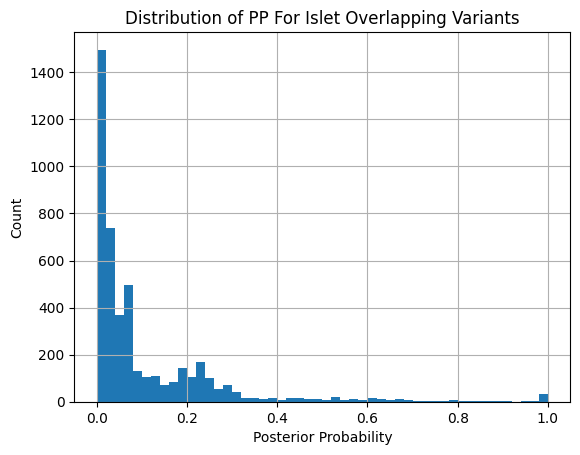

In [8]:
# what's the distribution of PP in islets?

islets['posteriorProbability'].hist(bins=50)
plt.xlabel('Posterior Probability')
plt.ylabel('Count')
plt.title('Distribution of PP For Islet Overlapping Variants')
plt.show()

In [9]:
# 12/05/2026
# save PP ≥ 0.5 variants as a BED file
# important to know that a single variant can appear in multiple studies
# so number of unique variants will be lower

import pandas as pd

cols = ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId',
        'posteriorProbability', 'studyId',
        'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']

islets = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_Islets.bed',
                     sep='\t', header=None, names=cols)

# PP >= 0.5
top_hits = islets[islets['posteriorProbability'] >= 0.5].copy()

print(f"Variants With PP >= 0.5: {len(top_hits)}")
print(f"Unique Variants: {top_hits['variantId'].nunique()}")

# save as BED
top_hits[['gwas_chr', 'gwas_start', 'gwas_end',
          'variantId', 'posteriorProbability', 'studyId']].to_csv(
    '/scratch/users/k21049150/HNF1A/top_hits_pp05.bed',
    sep='\t', header=False, index=False)

print("Saved to top_hits_pp05.bed")

Variants With PP >= 0.5: 189
Unique Variants: 31
Saved to top_hits_pp05.bed


In [10]:
# want to deduplicate on variantId for the bedtools step (since the genomic position is what matters there)
# then re-join the study/trait information back afterwards so you keep all the trait associations per variant

# deduplicated BED for bedtools (one row per unique genomic position)
top_hits.drop_duplicates(subset='variantId')[
    ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId', 'posteriorProbability', 'studyId']
].to_csv(
    '/scratch/users/k21049150/HNF1A/top_hits_pp05_dedup.bed',
    sep='\t', header=False, index=False)

print(f"Deduplicated BED written: {top_hits['variantId'].nunique()} variants")

Deduplicated BED written: 31 variants


In [11]:
!head /scratch/users/k21049150/HNF1A/top_hits_pp05_dedup.bed

chr1	18480844	18480845	1_18480845_T_C	0.733153905568867	GCST90454345
chr1	202010326	202010327	1_202010327_G_A	0.5188419102496334	GCST90692778
chr1	234960803	234960804	1_234960804_A_T	0.9782212378812102	GCST90013992
chr10	24902440	24902441	10_24902441_A_G	0.7483470586251415	GCST90691830
chr10	44911159	44911160	10_44911160_T_C	0.5494843752182805	GCST90474581
chr11	61757034	61757035	11_61757035_T_C	0.9990582331398826	GCST90278631
chr16	3459315	3459316	16_3459316_CTA_C	0.9957217944964388	GCST90617404
chr16	21261269	21261270	16_21261270_G_A	1.0	GCST90239652
chr16	69351737	69351738	16_69351738_A_G	0.5166571953141497	GCST90092859
chr18	26757459	26757460	18_26757460_C_G	0.5389638074907338	GCST011119


In [12]:
# load FIMO for Islets in
# load FIMO output

fimo = pd.read_csv('/scratch/users/k21049150/HNF1A/GSM6248576_MA0046.1.tsv',
    sep='\t', comment='#')

print(fimo.shape)
fimo.head(3)

(504, 10)


,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,MA0046.1,HNF1A,chr1_3219340-3219738,226,239,+,20.6465,6.290000e-09,0.00189,GGTTAATAATTACC
1,MA0046.1,HNF1A,chr14_70753531-70754024,232,245,-,20.1717,2.790000e-08,0.00248,GGTTAATTATTAAC
2,MA0046.1,HNF1A,chr6_43806460-43806827,124,137,+,19.9293,3.300000e-08,0.00248,GGTTAATGATTACC


In [13]:
# convert FIMO relative positions to absolute coordinates before we can do distance calculations

# sequence_name is like "chr7_131088463-131088788"
# start/stop are 1-based positions within that sequence

# parse peak chr, peak_start from sequence_name
fimo[['peak_chr', 'peak_coords']] = fimo['sequence_name'].str.split('_', n=1, expand=True)
fimo[['peak_abs_start', 'peak_abs_end']] = fimo['peak_coords'].str.split('-', expand=True).astype(int)

# convert motif positions to absolute genome coords (FIMO is 1-based, convert to 0-based BED)
fimo['motif_abs_start'] = fimo['peak_abs_start'] + fimo['start'] - 1
fimo['motif_abs_end']   = fimo['peak_abs_start'] + fimo['stop']

print(fimo[['peak_chr', 'motif_abs_start', 'motif_abs_end', 'strand', 'score', 'matched_sequence']].head(5))
print(f"\nTotal motif hits: {len(fimo)}")

  peak_chr  motif_abs_start  motif_abs_end strand    score matched_sequence
0     chr1          3219565        3219579      +  20.6465   GGTTAATAATTACC
1    chr14         70753762       70753776      -  20.1717   GGTTAATTATTAAC
2     chr6         43806583       43806597      +  19.9293   GGTTAATGATTACC
3     chr6         12363996       12364010      -  19.9293   GGTTAATGATTACC
4    chr12         92070511       92070525      +  19.0404   GGTTAATTATTAGC

Total motif hits: 504


In [14]:
# find the nearest gene to each of the 31 variants

# nearest gene from bedtools closest output
bt_cols = ['gwas_chr','gwas_start','gwas_end','variantId','posteriorProbability','studyId',
           'g_chr','g_start','g_end','gene_name','g_score','g_strand','distance_to_gene']

bt_islet = pd.read_csv('/scratch/users/k21049150/HNF1A/nearest_gene_Islets.bed',
                       sep='\t', header=None, names=bt_cols)

# collapse ties: where a variant is equidistant from >1 gene, prefer a named symbol over an ENSG id
bt_islet['is_ensg'] = bt_islet['gene_name'].str.startswith('ENSG')
bt_islet = (bt_islet.sort_values(['variantId','is_ensg'])      # named genes first
                    .drop_duplicates('variantId', keep='first'))

nearest_gene_df = bt_islet[['variantId','posteriorProbability','gene_name','distance_to_gene']].copy()
nearest_gene_df = nearest_gene_df.rename(columns={'gene_name':'nearest_gene'})
nearest_gene_df['inside_gene'] = nearest_gene_df['distance_to_gene'] == 0

print(f"Variants: {len(nearest_gene_df)}")
print(nearest_gene_df.sort_values('posteriorProbability', ascending=False).to_string())

Variants: 31
           variantId  posteriorProbability nearest_gene  distance_to_gene  inside_gene
8    16_21261270_G_A              1.000000         CRYM                 0         True
19   20_22411796_T_A              1.000000        FOXA2            169202        False
20   22_18061609_G_A              1.000000        PEX26             16314        False
22     3_9897979_T_C              1.000000        JAGN1              3630        False
32   8_118383295_A_C              0.999997       SAMD12                 0         True
14    2_43194322_T_C              0.999283      ZFP36L2             28080        False
5    11_61757035_T_C              0.999058         MYRF                 0         True
7   16_3459316_CTA_C              0.995722        NAA60                 0         True
17    2_62570365_T_C              0.992881       TMEM17             58471        False
2    1_234960804_A_T              0.978221       TOMM20            148537        False
26    5_21768177_G_A          

In [15]:
# reload with full column set including peak coordinates
full_cols = ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId',
             'posteriorProbability', 'studyId',
             'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']

islets_full = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_Islets.bed',
                          sep='\t', header=None, names=full_cols)

# filter PP >= 0.5, keeping peak coordinates this time
variants = (islets_full[islets_full['posteriorProbability'] >= 0.5]
             .drop_duplicates(subset='variantId')
            .reset_index(drop=True))

print(variants.columns.tolist())
print(f"Variants: {len(variants)}")
print(variants[['variantId', 'peak_start', 'peak_end']].head(3))

['gwas_chr', 'gwas_start', 'gwas_end', 'variantId', 'posteriorProbability', 'studyId', 'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']
Variants: 31
         variantId  peak_start   peak_end
0   1_18480845_T_C    18480799   18481093
1  1_202010327_G_A   202010175  202010594
2  1_234960804_A_T   234960679  234960986


In [16]:
fimo_bed = fimo[['peak_chr', 'motif_abs_start', 'motif_abs_end', 'matched_sequence', 'strand', 'score']].copy()

results_motif = []

for _, var in variants.iterrows():
    chrom      = var['gwas_chr']
    pos        = var['gwas_end']
    peak_start = var['peak_start']
    peak_end   = var['peak_end']

    # find motifs within the same peak only
    same_peak = fimo_bed[
        (fimo_bed['peak_chr'] == chrom) &
        (fimo_bed['motif_abs_start'] >= peak_start) &
        (fimo_bed['motif_abs_end']   <= peak_end)
    ].copy()

    # if no motif in this peak, record that
    if same_peak.empty:
        results_motif.append({
            'variantId':         var['variantId'],
            'distance_to_motif': None,
            'inside_motif':      False,
            'motif_sequence':    None,
            'note':              'no motif in peak'
        })
        continue

    # calculate distance from variant to each motif in the peak
    same_peak['dist'] = np.where(
        (pos >= same_peak['motif_abs_start']) & (pos <= same_peak['motif_abs_end']), 0,
        np.where(pos < same_peak['motif_abs_start'],
                 pos - same_peak['motif_abs_start'],   # negative = upstream of motif
                 pos - same_peak['motif_abs_end'])      # positive = downstream of motif
    )

    # keep the closest motif
    nearest = same_peak.loc[same_peak['dist'].abs().idxmin()]

    results_motif.append({
        'variantId':         var['variantId'],
        'distance_to_motif': int(nearest['dist']),
        'inside_motif':      nearest['dist'] == 0,
        'motif_sequence':    nearest['matched_sequence'],
        'note':              'motif found in peak'
    })

motif_df = pd.DataFrame(results_motif)
print(motif_df.sort_values('inside_motif', ascending=False).to_string())

           variantId  distance_to_motif  inside_motif  motif_sequence                 note
5    11_61757035_T_C                0.0          True  AGTTAATAATTTCT  motif found in peak
26    6_43833917_C_T                0.0          True  TGTTAATAATTACC  motif found in peak
0     1_18480845_T_C              -82.0         False  GATTAATAATTGCC  motif found in peak
16   2_232782018_A_T               -2.0         False  GGTTATTTATTTAC  motif found in peak
29    7_48089060_T_A               92.0         False  TGTTACTCATTAAA  motif found in peak
28   6_160254732_T_C             -162.0         False  AGTTAATTATTCAC  motif found in peak
27   6_125899862_G_A               13.0         False  AGTTAATCATTCAC  motif found in peak
25    6_43833845_C_T              -59.0         False  TGTTAATAATTACC  motif found in peak
24    5_21768177_G_A              -56.0         False  AGTTACTAATTTGA  motif found in peak
23   3_172595577_T_C             -138.0         False  AGTTAATCAATTAA  motif found in peak

In [17]:
# merge nearest gene + motif distance together
final = nearest_gene_df.merge(motif_df, on='variantId')

# bring in PP from variants, not PP (already in nearest_gene_df)
final = final.merge(
    variants[['variantId', 'peak_chr', 'peak_start', 'peak_end']],
    on='variantId')

# sort by PP descending
final = final.sort_values('posteriorProbability', ascending=False).reset_index(drop=True)

final = final[[
    'variantId', 'posteriorProbability',
    'nearest_gene', 'distance_to_gene', 'inside_gene',
    'distance_to_motif', 'inside_motif', 'motif_sequence', 'note']]

print(final.to_string())

           variantId  posteriorProbability nearest_gene  distance_to_gene  inside_gene  distance_to_motif  inside_motif  motif_sequence                 note
0    16_21261270_G_A              1.000000         CRYM                 0         True              136.0         False  TGTAAATAATTGAC  motif found in peak
1    20_22411796_T_A              1.000000        FOXA2            169202        False               61.0         False  GGTTAATCATTACA  motif found in peak
2    22_18061609_G_A              1.000000        PEX26             16314        False              125.0         False  TGTTAATGTTTAAC  motif found in peak
3      3_9897979_T_C              1.000000        JAGN1              3630        False              -63.0         False  GATTAATGATTAAT  motif found in peak
4    8_118383295_A_C              0.999997       SAMD12                 0         True                NaN         False            None     no motif in peak
5     2_43194322_T_C              0.999283      ZFP36L2   

In [18]:
# get the studies for the in-motif variants and look up their traits

# the variants where inside_motif == True
motif_vars = final.loc[final['inside_motif'] == True, 'variantId'].tolist()
print("In-motif variants:", motif_vars)

# pull every PP>=0.5 study row for just those variants (a variant can map to several studies)
pp05 = islets[islets['posteriorProbability'] >= 0.5]
motif_rows = pp05[pp05['variantId'].isin(motif_vars)][['variantId', 'studyId']].drop_duplicates()

# look up the trait for each study
results = []
for _, row in motif_rows.iterrows():
    url = f"https://www.ebi.ac.uk/gwas/rest/api/studies/{row['studyId']}"
    try:
        r = requests.get(url, timeout=20)
        trait = r.json().get('diseaseTrait', {}).get('trait', 'Unknown') if r.status_code == 200 else 'Not found'
    except Exception:
        trait = 'Error'
    results.append({'variantId': row['variantId'], 'studyId': row['studyId'], 'trait': trait})
    time.sleep(0.1)

motif_traits = pd.DataFrame(results)
print(motif_traits.to_string())

In-motif variants: ['11_61757035_T_C', '6_43833917_C_T']
          variantId       studyId                                                      trait
0   11_61757035_T_C  GCST90278631                                                 Hemoglobin
1    6_43833917_C_T  GCST90271558                                      Random glucose levels
2    6_43833917_C_T  GCST90475380                 hemoglobin (minimum, inv-norm transformed)
3    6_43833917_C_T  GCST90002384                                                 Hemoglobin
4    6_43833917_C_T  GCST90271557                                      Random glucose levels
5    6_43833917_C_T  GCST90475091      Hemoglobin A1c (HbA1c, maximum, inv-norm transformed)
6    6_43833917_C_T  GCST90475341                    hematocrit (mean, inv-norm transformed)
7    6_43833917_C_T  GCST90019508                                       Blood glucose levels
8    6_43833917_C_T  GCST90014005                      Glucose levels (UKB data field 30740)
9    6_438339

In [19]:
# one row per variant, with gene + motif sequence + traits

collapsed = (motif_traits.groupby('variantId')['trait']
             .apply(lambda s: '; '.join(sorted(set(s.dropna()))))
             .reset_index().rename(columns={'trait': 'traits'}))

motif_summary = final.loc[final['inside_motif'] == True,
                          ['variantId', 'posteriorProbability', 'nearest_gene', 'motif_sequence']] \
                     .merge(collapsed, on='variantId')

print(motif_summary.to_string())

         variantId  posteriorProbability nearest_gene  motif_sequence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       traits
0  11_61757035_T_C              0.999058         MYRF  AGTTAATAATTTCT                                                                                                                                                                                                                                                                

## Islet Plots

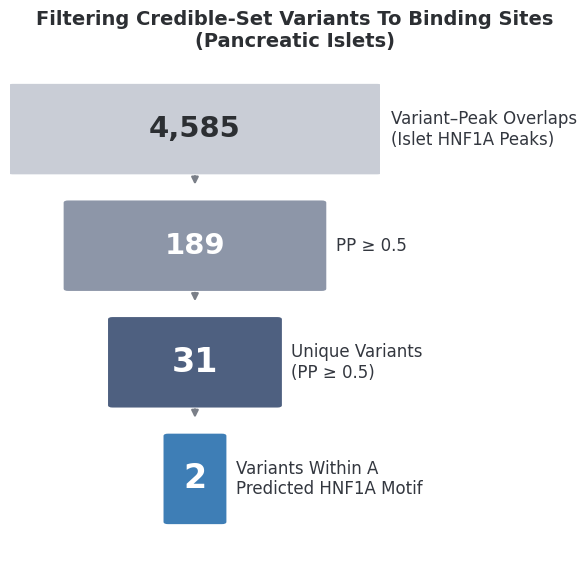

In [48]:
# pull the four stage counts straight from existing dataframes
n_overlaps = len(islets)                                              # all credible-set variant–peak overlaps
n_pp05     = int((islets['posteriorProbability'] >= 0.5).sum())       # overlaps at PP >= 0.5
n_unique   = islets.loc[islets['posteriorProbability'] >= 0.5,
                        'variantId'].nunique()                        # unique variants at PP >= 0.5
n_inmotif  = int(final['inside_motif'].sum())                         # variants inside a FIMO motif

# colour palette
TITLE_COL = "#2c2f33"          # near-black for title text
BOX1_COL  = "#c9cdd6"          # light slate-grey  (top box)
BOX2_COL  = "#8d96a8"          # mid slate-blue    (second box)
BOX3_COL  = "#4e6080"          # muted steel-blue  (third box)
BOX4_COL  = "#3E7EB6"          # blue  (bottom box)

stages = [
    (f"{n_overlaps:,}", "Variant\u2013Peak Overlaps\n(Islet HNF1A Peaks)", BOX1_COL, "#2c2f33"),
    (f"{n_pp05:,}",     "PP \u2265 0.5",                                              BOX2_COL, "white"),
    (f"{n_unique:,}",   "Unique Variants\n(PP \u2265 0.5)",                               BOX3_COL, "white"),
    (f"{n_inmotif:,}",  "Variants Within A\nPredicted HNF1A Motif",                               BOX4_COL, "white"),]

widths = [1.0, 0.70, 0.46, 0.16]

fig, ax = plt.subplots(figsize=(6, 5.6))
ax.axis("off")
ytop, ybot, cx = 0.94, 0.06, 0.5
band = (ytop - ybot) / len(stages)

for i, ((val, label, color, txtcol), w) in enumerate(zip(stages, widths)):
    y = ytop - (i + 1) * band + band * 0.12
    h = band * 0.76
    ax.add_patch(FancyBboxPatch((cx - w/2, y), w, h,
                 boxstyle="round,pad=0.005,rounding_size=0.012",
                 lw=0, facecolor=color, mutation_aspect=0.35, transform=ax.transAxes))
    ax.text(cx, y + h/2, val, ha="center", va="center",
            fontsize=21 if i < 2 else 24, fontweight="bold", color=txtcol, transform=ax.transAxes)
    ax.text(cx + w/2 + 0.03, y + h/2, label, ha="left", va="center",
            fontsize=12, color="#33373f", transform=ax.transAxes)
    if i < len(stages) - 1:
        ax.annotate("", xy=(cx, y - band*0.12), xytext=(cx, y), transform=ax.transAxes,
                    arrowprops=dict(arrowstyle="-|>", color="#7a7f88", lw=1.6))

# title: centred over full axes width
fig.text(0.5, 1.025,
         "Filtering Credible-Set Variants To Binding Sites\n(Pancreatic Islets)", ha="center", va="top", fontsize=14, fontweight="bold", color=TITLE_COL)

plt.tight_layout()
plt.show()

## Hepatocyte Analysis

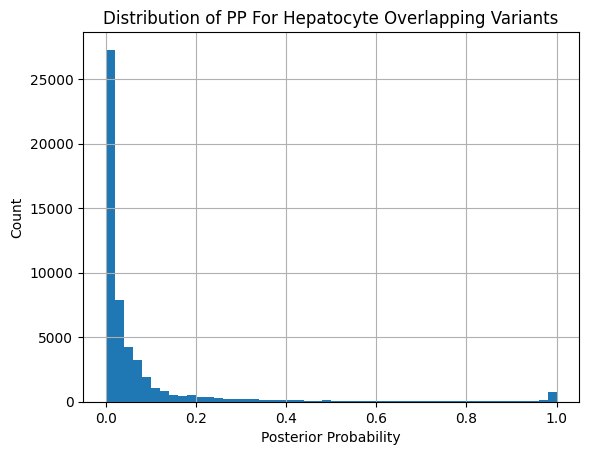

In [22]:
# what's the distribution of PP in islets?
hepg2['posteriorProbability'].hist(bins=50)
plt.xlabel('Posterior Probability')
plt.ylabel('Count')
plt.title('Distribution of PP For Hepatocyte Overlapping Variants')
plt.show()

In [23]:
# 03/06/2026
# save PP ≥ 0.5 variants as a BED file
# important to know that a single variant can appear in multiple studies
# so number of unique variants will be lower

cols = ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId',
        'posteriorProbability', 'studyId',
        'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']

hepg2 = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_HepG2.bed',
                    sep='\t', header=None, names=cols)

hep_top_hits = hepg2[hepg2['posteriorProbability'] >= 0.5].copy()

print(f"Variants With PP >= 0.5: {len(hep_top_hits)}")
print(f"Unique Variants: {hep_top_hits['variantId'].nunique()}")

hep_top_hits[['gwas_chr', 'gwas_start', 'gwas_end',
              'variantId', 'posteriorProbability', 'studyId']].to_csv(
    '/scratch/users/k21049150/HNF1A/hep_top_hits_pp05.bed',
    sep='\t', header=False, index=False)

print("Saved to hep_top_hits_pp05.bed")

Variants With PP >= 0.5: 2475
Unique Variants: 368
Saved to hep_top_hits_pp05.bed


In [24]:
# want to deduplicate on variantId for the bedtools step (since the genomic position is what matters there)
# then re-join the study/trait information back afterwards so you keep all the trait associations per variant

# deduplicated BED for bedtools (one row per unique genomic position)
hep_top_hits.drop_duplicates(subset='variantId')[
    ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId', 'posteriorProbability', 'studyId']
].to_csv(
    '/scratch/users/k21049150/HNF1A/hep_top_hits_pp05_dedup.bed',
    sep='\t', header=False, index=False)

print(f"Deduplicated BED written: {hep_top_hits['variantId'].nunique()} variants")

Deduplicated BED written: 368 variants


In [25]:
# load FIMO for HepG2 in
# load FIMO output

hep_fimo = pd.read_csv('/scratch/users/k21049150/HNF1A/GSM6248577_MA0046.1.tsv',
    sep='\t', comment='#')

print(hep_fimo.shape)
hep_fimo.head(3)

(4138, 10)


,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,MA0046.1,HNF1A,chr6_24193456-24193760,112,125,-,20.6465,6.290000e-09,0.00603,GGTTAATAATTACC
1,MA0046.1,HNF1A,chr2_162091616-162091961,167,180,+,20.6465,6.290000e-09,0.00603,GGTTAATAATTACC
2,MA0046.1,HNF1A,chr6_89140202-89140703,240,253,-,20.6465,6.290000e-09,0.00603,GGTTAATAATTACC


In [26]:
# convert FIMO relative positions to absolute coordinates before we can do distance calculations

# sequence_name is like "chr7_131088463-131088788"
# start/stop are 1-based positions within that sequence

hep_fimo[['peak_chr', 'peak_coords']] = hep_fimo['sequence_name'].str.split('_', n=1, expand=True)
hep_fimo[['peak_abs_start', 'peak_abs_end']] = hep_fimo['peak_coords'].str.split('-', expand=True).astype(int)

hep_fimo['motif_abs_start'] = hep_fimo['peak_abs_start'] + hep_fimo['start'] - 1
hep_fimo['motif_abs_end']   = hep_fimo['peak_abs_start'] + hep_fimo['stop']

print(hep_fimo[['peak_chr', 'motif_abs_start', 'motif_abs_end', 'strand', 'score', 'matched_sequence']].head(5))
print(f"\nTotal motif hits: {len(hep_fimo)}")

  peak_chr  motif_abs_start  motif_abs_end strand    score matched_sequence
0     chr6         24193567       24193581      -  20.6465   GGTTAATAATTACC
1     chr2        162091782      162091796      +  20.6465   GGTTAATAATTACC
2     chr6         89140441       89140455      -  20.6465   GGTTAATAATTACC
3     chr1          3219565        3219579      +  20.6465   GGTTAATAATTACC
4    chr21         41498099       41498113      -  20.4545   GGTTAATTATTACC

Total motif hits: 4138


In [27]:
# find the nearest gene to each of the 368 variants

# nearest gene from bedtools closest output
bt_hep = pd.read_csv('/scratch/users/k21049150/HNF1A/nearest_gene_HepG2.bed',
                     sep='\t', header=None, names=bt_cols)

# collapse ties: where a variant is equidistant from >1 gene, prefer a named symbol over an ENSG id
bt_hep['is_ensg'] = bt_hep['gene_name'].str.startswith('ENSG')
bt_hep = (bt_hep.sort_values(['variantId','is_ensg'])
                .drop_duplicates('variantId', keep='first'))

hep_nearest_gene_df = bt_hep[['variantId','posteriorProbability','gene_name','distance_to_gene']].copy()
hep_nearest_gene_df = hep_nearest_gene_df.rename(columns={'gene_name':'nearest_gene'})
hep_nearest_gene_df['inside_gene'] = hep_nearest_gene_df['distance_to_gene'] == 0

print(f"Variants: {len(hep_nearest_gene_df)}")
print(hep_nearest_gene_df.sort_values('posteriorProbability', ascending=False).to_string())

Variants: 368
                  variantId  posteriorProbability     nearest_gene  distance_to_gene  inside_gene
371          8_27603616_C_A              1.000000              CLU                 0         True
377         8_122757086_G_C              1.000000             ZHX2             24569        False
362          7_96308614_C_T              1.000000         SLC25A13                 0         True
39          10_93601934_A_C              1.000000            FFAR4                 0         True
52          11_27187784_C_T              1.000000            BBOX1             59975        False
337          6_52389509_T_A              1.000000            PAQR8                 0         True
73          12_50241559_C_T              1.000000            LIMA1                 0         True
96         13_107120442_C_T              1.000000            NALF1             43068        False
91          13_23610055_T_C              1.000000         TNFRSF19                 0         True
89    

In [28]:
# reload with full column set including peak coordinates

full_cols = ['gwas_chr', 'gwas_start', 'gwas_end', 'variantId',
             'posteriorProbability', 'studyId',
             'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']

hepg2_full = pd.read_csv('/scratch/users/k21049150/HNF1A/hits_HepG2.bed',
                         sep='\t', header=None, names=full_cols)

hep_variants = (hepg2_full[hepg2_full['posteriorProbability'] >= 0.5]
                 .drop_duplicates(subset='variantId')
                 .reset_index(drop=True))

print(hep_variants.columns.tolist())
print(f"Variants: {len(hep_variants)}")
print(hep_variants[['variantId', 'peak_start', 'peak_end']].head(3))

['gwas_chr', 'gwas_start', 'gwas_end', 'variantId', 'posteriorProbability', 'studyId', 'peak_chr', 'peak_start', 'peak_end', 'peak_name', 'peak_score', 'peak_strand']
Variants: 368
        variantId  peak_start  peak_end
0   1_8169959_T_C     8169708   8170318
1   1_9435490_G_A     9435084   9435617
2  1_16178825_A_G    16178397  16178879


In [29]:
# distance from each variant to nearest motif in its peak

hep_fimo_bed = hep_fimo[['peak_chr', 'motif_abs_start', 'motif_abs_end', 'matched_sequence', 'strand', 'score']].copy()

results_motif = []
for _, var in hep_variants.iterrows():
    chrom      = var['gwas_chr']
    pos        = var['gwas_end']
    peak_start = var['peak_start']
    peak_end   = var['peak_end']

    same_peak = hep_fimo_bed[
        (hep_fimo_bed['peak_chr'] == chrom) &
        (hep_fimo_bed['motif_abs_start'] >= peak_start) &
        (hep_fimo_bed['motif_abs_end']   <= peak_end)
    ].copy()

    if same_peak.empty:
        results_motif.append({
            'variantId':         var['variantId'],
            'distance_to_motif': None,
            'inside_motif':      False,
            'motif_sequence':    None,
            'note':              'no motif in peak'
        })
        continue

    same_peak['dist'] = np.where(
        (pos >= same_peak['motif_abs_start']) & (pos <= same_peak['motif_abs_end']), 0,
        np.where(pos < same_peak['motif_abs_start'],
                 pos - same_peak['motif_abs_start'],
                 pos - same_peak['motif_abs_end'])
    )

    nearest = same_peak.loc[same_peak['dist'].abs().idxmin()]

    results_motif.append({
        'variantId':         var['variantId'],
        'distance_to_motif': int(nearest['dist']),
        'inside_motif':      nearest['dist'] == 0,
        'motif_sequence':    nearest['matched_sequence'],
        'note':              'motif found in peak'
    })

hep_motif_df = pd.DataFrame(results_motif)
print(hep_motif_df.sort_values('inside_motif', ascending=False).to_string())

                  variantId  distance_to_motif  inside_motif  motif_sequence                 note
184          2_43806615_T_G                0.0          True  GATTAATATTTATC  motif found in peak
204         2_191247926_A_G                0.0          True  AGTTAGTCTTTAAC  motif found in peak
117         15_96171517_T_G                0.0          True  AGTTAATCTTCAAT  motif found in peak
310          6_11217664_T_C                0.0          True  AGTTAATGATTTGC  motif found in peak
313          6_43833917_C_T                0.0          True  TGTTAATAATTACC  motif found in peak
57          11_64555533_A_G                0.0          True  GGTTAAAGTTTAAT  motif found in peak
317          6_56399929_T_C                0.0          True  TGTTAATTATTCAC  motif found in peak
51          11_61757035_T_C                0.0          True  AGTTAATAATTTCT  motif found in peak
225         20_46607483_T_A                0.0          True  GGTTAATGATCAGC  motif found in peak
219         20_40887

In [30]:
# merge into the final table 

hep_final = hep_nearest_gene_df.merge(hep_motif_df, on='variantId')

hep_final = hep_final.merge(
    hep_variants[['variantId', 'peak_chr', 'peak_start', 'peak_end']],
    on='variantId')

hep_final = hep_final.sort_values('posteriorProbability', ascending=False).reset_index(drop=True)

hep_final = hep_final[[
    'variantId', 'posteriorProbability',
    'nearest_gene', 'distance_to_gene', 'inside_gene',
    'distance_to_motif', 'inside_motif', 'motif_sequence', 'note']]

print(hep_final.to_string())
print(f"\nVariants Inside A Motif: {int(hep_final['inside_motif'].sum())}")

                  variantId  posteriorProbability     nearest_gene  distance_to_gene  inside_gene  distance_to_motif  inside_motif  motif_sequence                 note
0            8_27603616_C_A              1.000000              CLU                 0         True              132.0         False  AGTTAATTGTTTCC  motif found in peak
1           8_122757086_G_C              1.000000             ZHX2             24569        False                NaN         False            None     no motif in peak
2            7_96308614_C_T              1.000000         SLC25A13                 0         True               36.0         False  AGTTAATCTTTAAA  motif found in peak
3           10_93601934_A_C              1.000000            FFAR4                 0         True                NaN         False            None     no motif in peak
4           11_27187784_C_T              1.000000            BBOX1             59975        False              229.0         False  GGTAAATGTTTAAC  motif found 

In [31]:
# get the studies for the in-motif HepG2 variants and look up their traits

# the variants where inside_motif == True
hep_motif_vars = hep_final.loc[hep_final['inside_motif'] == True, 'variantId'].tolist()
print("In-motif variants:", hep_motif_vars)

# pull every PP>=0.5 study row for just those variants (a variant can map to several studies)
hep_pp05 = hepg2[hepg2['posteriorProbability'] >= 0.5]
hep_motif_rows = hep_pp05[hep_pp05['variantId'].isin(hep_motif_vars)][['variantId', 'studyId']].drop_duplicates()

# look up the trait for each study
results = []
for _, row in hep_motif_rows.iterrows():
    url = f"https://www.ebi.ac.uk/gwas/rest/api/studies/{row['studyId']}"
    try:
        r = requests.get(url, timeout=20)
        trait = r.json().get('diseaseTrait', {}).get('trait', 'Unknown') if r.status_code == 200 else 'Not found'
    except Exception:
        trait = 'Error'
    results.append({'variantId': row['variantId'], 'studyId': row['studyId'], 'trait': trait})
    time.sleep(0.1)

hep_motif_traits = pd.DataFrame(results)
print(hep_motif_traits.to_string())

In-motif variants: ['11_61757035_T_C', '15_96171517_T_G', '11_64555533_A_G', '20_40887300_C_T', '6_11217664_T_C', '2_191247926_A_G', '6_43833917_C_T', '2_43806615_T_G', '17_1736501_A_G', '6_56399929_T_C', '20_46607483_T_A', '1_213977102_T_A']
           variantId                             studyId                                                              trait
0    1_213977102_T_A                        GCST90475673    Type 2 diabetes with ophthalmic manifestations (PheCode 250.23)
1    1_213977102_T_A                        GCST90475103                               Albumin (mean, inv-norm transformed)
2    1_213977102_T_A                        GCST90475192                          chloride  (maximum, inv-norm transformed)
3    1_213977102_T_A                        GCST90475329    Glucose (fasting status unknown, maximum, inv-norm transformed)
4    1_213977102_T_A                        GCST90691658                 Diabetes diagnosed by doctor (UKB data field 2443)
5    1_213977

In [32]:
# one row per variant, with gene + motif sequence + traits

hep_collapsed = (hep_motif_traits.groupby('variantId')['trait']
                 .apply(lambda s: '; '.join(sorted(set(s.dropna()))))
                 .reset_index().rename(columns={'trait': 'traits'}))

hep_motif_summary = hep_final.loc[hep_final['inside_motif'] == True,
                                  ['variantId', 'posteriorProbability', 'nearest_gene', 'motif_sequence']] \
                            .merge(hep_collapsed, on='variantId')

print(hep_motif_summary.to_string())

          variantId  posteriorProbability nearest_gene  motif_sequence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## Hepatocyte Plots

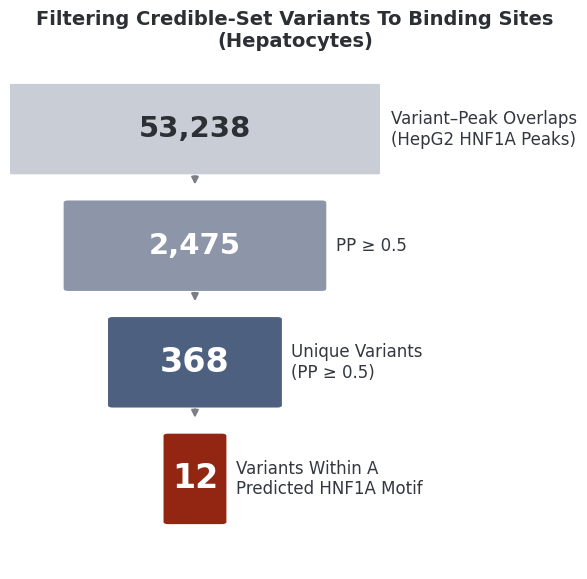

In [50]:
# pull the four stage counts straight from existing dataframes
n_overlaps = len(hepg2)                                               # all credible-set variant–peak overlaps
n_pp05     = int((hepg2['posteriorProbability'] >= 0.5).sum())        # overlaps at PP >= 0.5
n_unique   = hepg2.loc[hepg2['posteriorProbability'] >= 0.5,
                       'variantId'].nunique()                         # unique variants at PP >= 0.5
n_inmotif  = int(hep_final['inside_motif'].sum())                     # variants inside a FIMO motif

# colour palette
TITLE_COL = "#2c2f33"
BOX1_COL  = "#c9cdd6"
BOX2_COL  = "#8d96a8"
BOX3_COL  = "#4e6080"
BOX4_COL  = "#932513"

stages = [
    (f"{n_overlaps:,}", "Variant\u2013Peak Overlaps\n(HepG2 HNF1A Peaks)", BOX1_COL, "#2c2f33"),
    (f"{n_pp05:,}",     "PP \u2265 0.5",                                    BOX2_COL, "white"),
    (f"{n_unique:,}",   "Unique Variants\n(PP \u2265 0.5)",                  BOX3_COL, "white"),
    (f"{n_inmotif:,}",  "Variants Within A\nPredicted HNF1A Motif",         BOX4_COL, "white"),]
widths = [1.0, 0.70, 0.46, 0.16]

fig, ax = plt.subplots(figsize=(6, 5.6))
ax.axis("off")
ytop, ybot, cx = 0.94, 0.06, 0.5
band = (ytop - ybot) / len(stages)

for i, ((val, label, color, txtcol), w) in enumerate(zip(stages, widths)):
    y = ytop - (i + 1) * band + band * 0.12
    h = band * 0.76
    ax.add_patch(FancyBboxPatch((cx - w/2, y), w, h,
                 boxstyle="round,pad=0.005,rounding_size=0.012",
                 lw=0, facecolor=color, mutation_aspect=0.35, transform=ax.transAxes))
    ax.text(cx, y + h/2, val, ha="center", va="center",
            fontsize=21 if i < 2 else 24, fontweight="bold", color=txtcol, transform=ax.transAxes)
    ax.text(cx + w/2 + 0.03, y + h/2, label, ha="left", va="center",
            fontsize=12, color="#33373f", transform=ax.transAxes)
    if i < len(stages) - 1:
        ax.annotate("", xy=(cx, y - band*0.12), xytext=(cx, y), transform=ax.transAxes,
                    arrowprops=dict(arrowstyle="-|>", color="#7a7f88", lw=1.6))

# title: centred over full axes width
fig.text(0.5, 1.025,
         "Filtering Credible-Set Variants To Binding Sites\n(Hepatocytes)", ha="center", va="top", fontsize=14, fontweight="bold", color=TITLE_COL)

plt.tight_layout()
plt.show()

## Variant Traits

In [5]:
from IPython.display import display

# parse chr and position out of variantId (format: chr_pos_ref_alt)
def parse_coords(df):
    df = df.copy()
    parts = df['variantId'].str.split('_', expand=True)
    df['chromosome'] = parts[0]
    df['position']   = parts[1].astype(int)
    return df

# build a per-tissue table from its in-motif summary frame
def build_table(summary_df, tissue_label):
    t = parse_coords(summary_df)[[
        'variantId', 'chromosome', 'position',
        'posteriorProbability', 'nearest_gene',
        'motif_sequence', 'traits'
    ]].rename(columns={
        'variantId':            'Variant ID',
        'chromosome':           'Chr',
        'position':             'Position',
        'posteriorProbability': 'PP',
        'nearest_gene':         'Nearest Gene',
        'motif_sequence':       'Motif Sequence',
        'traits':               'GWAS Trait(s)'
    })
    t.insert(0, 'Tissue', tissue_label)
    t['PP'] = t['PP'].round(3)
    return t

islet_table = build_table(motif_summary,     'Pancreatic Islets')
hep_table   = build_table(hep_motif_summary,  'HepG2 Hepatocytes')

combined_table = pd.concat([islet_table, hep_table], ignore_index=True)

print(f"{len(combined_table)} tissue-level hits across "
      f"{combined_table['Variant ID'].nunique()} unique variants")

# wrap long trait strings so they don't explode the table width
def wrap_traits(s, max_chars=60):
    if len(s) <= max_chars:
        return s
    traits, lines, current = s.split('; '), [], ''
    for t in traits:
        if len(current) + len(t) > max_chars and current:
            lines.append(current.rstrip('; '))
            current = t + '; '
        else:
            current += t + '; '
    if current:
        lines.append(current.rstrip('; '))
    return '\n'.join(lines)

display_table = combined_table.copy()
display_table['GWAS Trait(s)'] = display_table['GWAS Trait(s)'].apply(wrap_traits)

# styled display so traits are easier to read
styled = (display_table.style
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'font-size': '12px',
        'padding': '6px 10px'
    })
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#4e6080'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('font-size', '12px'),
            ('padding', '6px 10px')
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#f2f4f7')
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#dde3ec')]},])
    .hide(axis='index')
    .format({'PP': '{:.3f}'}))

display(styled)

14 tissue-level hits across 12 unique variants


Tissue,Variant ID,Chr,Position,PP,Nearest Gene,Motif Sequence,GWAS Trait(s)
Pancreatic Islets,11_61757035_T_C,11,61757035,0.999,MYRF,AGTTAATAATTTCT,Hemoglobin; Water consumption corrected for coffee
Pancreatic Islets,6_43833917_C_T,6,43833917,0.541,VEGFA,TGTTAATAATTACC,"Blood glucose levels; Diabetes mellitus (PheCode 250) Glucose (fasting status unknown, maximum, inv-norm transformed) Glucose levels (UKB data field 30740) Glycated haemoglobin HbA1c levels (UKB data field 30750) Glycated hemoglobin HbA1c levels; Glycated hemoglobin levels Haematocrit percentage (UKB data field 30030) Haemoglobin concentration (UKB data field 30020); Hematocrit Hemoglobin Hemoglobin A1c (HbA1c, maximum, inv-norm transformed) Hemoglobin A1c (HbA1c, mean, inv-norm transformed) Hemoglobin concentration; Not found; Random glucose levels Red blood cell (erythrocyte) count (UKB data field 30010) Red blood cell count Red blood cell erythrocyte count (UKB data field 30010) Serum glycated hemoglobin levels Type 2 diabetes (PheCode 250.2) hematocrit (mean, inv-norm transformed) hematocrit (minimum, inv-norm transformed) hemoglobin (maximum, inv-norm transformed) hemoglobin (mean, inv-norm transformed) hemoglobin (minimum, inv-norm transformed) red blood cell count (RBC, maximum, inv-norm transformed) red blood cell count (RBC, mean, inv-norm transformed) red blood cell count (RBC, minimum, inv-norm transformed) red cell diameter width (RDW, mean, inv-norm transformed) red cell diameter width (RDW, minimum, inv-norm transformed)"
HepG2 Hepatocytes,11_61757035_T_C,11,61757035,0.999,MYRF,AGTTAATAATTTCT,Hemoglobin; Water consumption corrected for coffee
HepG2 Hepatocytes,11_64555533_A_G,11,64555533,0.889,SLC22A11,GGTTAAAGTTTAAT,Gout (PheCode 274.1) Gout and other crystal arthrop (PheCode 274) Takes medication for gout?
HepG2 Hepatocytes,15_96171517_T_G,15,96171517,0.976,NR2F2,AGTTAATCTTCAAT,Free androgen index; Free testosterone levels; SHBG levels Serum levels of protein SHBG; Serum testosterone levels Sex hormone binding globulin levels (UKB data field 30830) Sex hormone-binding globulin levels Total testosterone levels
HepG2 Hepatocytes,17_1736501_A_G,17,1736501,0.502,WDR81,GGTTACTCATTAGA,Albumin levels; Albumin levels (UKB data field 23479) Albumin levels (UKB data field 30600) Albumin-globulin ratio; Calcium levels Calcium levels (UKB data field 30680); Error Non-HDL cholesterol levels; SHBG levels Sex hormone binding globulin levels (UKB data field 30830) Sex hormone-binding globulin levels; Total protein levels Total testosterone levels; Triglyceride levels
HepG2 Hepatocytes,1_213977102_T_A,1,213977102,0.500,PROX1,GGTTAATTATTGAC,"Alanine levels; Alanine levels (UKB data field 23460) Albumin (maximum, inv-norm transformed) Albumin (mean, inv-norm transformed); Albumin levels Albumin levels (UKB data field 30600); Blood glucose levels Diabetes; Diabetes (confirmatory factor analysis Factor 28) Diabetes / ""Sugar"" Diabetes diagnosed by doctor (UKB data field 2443) Diabetes mellitus (PheCode 250) Diabetes mellitus (UKB data field 2443) Diabetic retinopathy (PheCode 250.7); Error Gamma glutamyl transferase levels Glucose (fasting status unknown, maximum, inv-norm transformed) Glucose levels; Glucose levels (UKB data field 23470) Glucose levels (UKB data field 30740); Glutamine levels Glutamine levels (UKB data field 23461) Glycated haemoglobin HbA1c levels (UKB data field 30750) Glycated hemoglobin HbA1c levels; Glycated hemoglobin levels Glycine levels; Glycine levels (UKB data field 23462) Hemoglobin A1c (HbA1c, maximum, inv-norm transformed) Hemoglobin A1c (HbA1c, mean, inv-norm transformed) Hemoglobin A1c (HbA1c, minimum, inv-norm transformed) Histidine levels; ICD10 E08-E13: Diabetes mellitus ICD10 E11: Non-insulin-dependent diabetes mellitus ICD10 E14: Unspecified diabetes mellitus; Isoleucine levels LDL direct, adjusted by medication; Leucine levels Low density lipoprotein cholesterol levels Medication use (drugs used in diabetes) Medication use fo